In [1]:
import pandas
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
DATA_PATH = './2'

fc = 20 * 10**3 #гц
det1 = np.load(DATA_PATH + '/det1.npy')
det2 = np.load(DATA_PATH + '/det2.npy')
len(det1)

199999

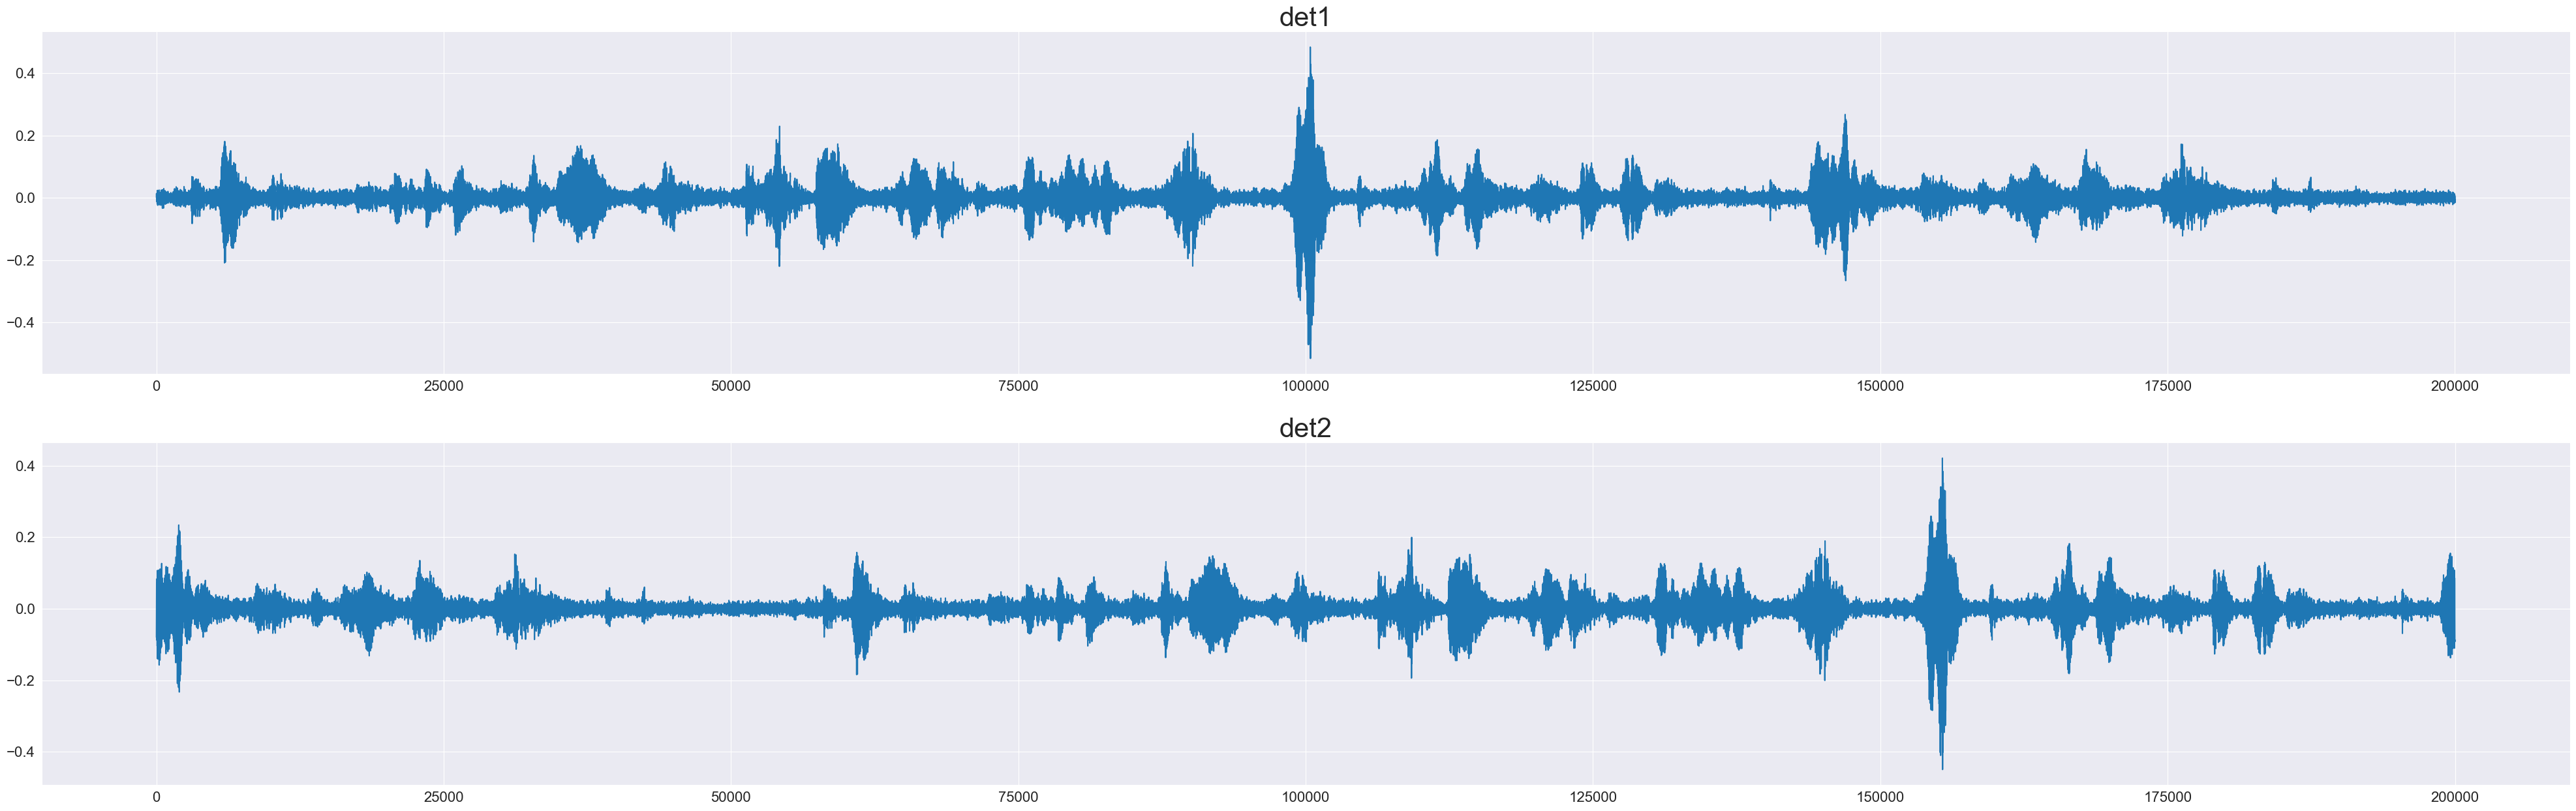

In [3]:
fig, ax = plt.subplots(2,1, figsize=(50,15))
ax[0].plot(det1)
ax[1].plot(det2)

ax[0].set_title('det1', fontsize=30)
ax[1].set_title('det2', fontsize=30)

for i in ax:
    i.tick_params(axis='both', labelsize=16)

In [4]:
from scipy.signal import correlate, correlation_lags

corr = correlate(det2, det1, mode="full", method="fft")
lags = correlation_lags(len(det2), len(det1), mode="full")

lag_samples = lags[np.argmax(corr)]
delay_seconds = lag_samples / fc

print(lag_samples)     # 55000
print(delay_seconds)   # 2.75
print(f"{delay_seconds:.1f} с")  # 2.8

55000
2.75
2.8 с


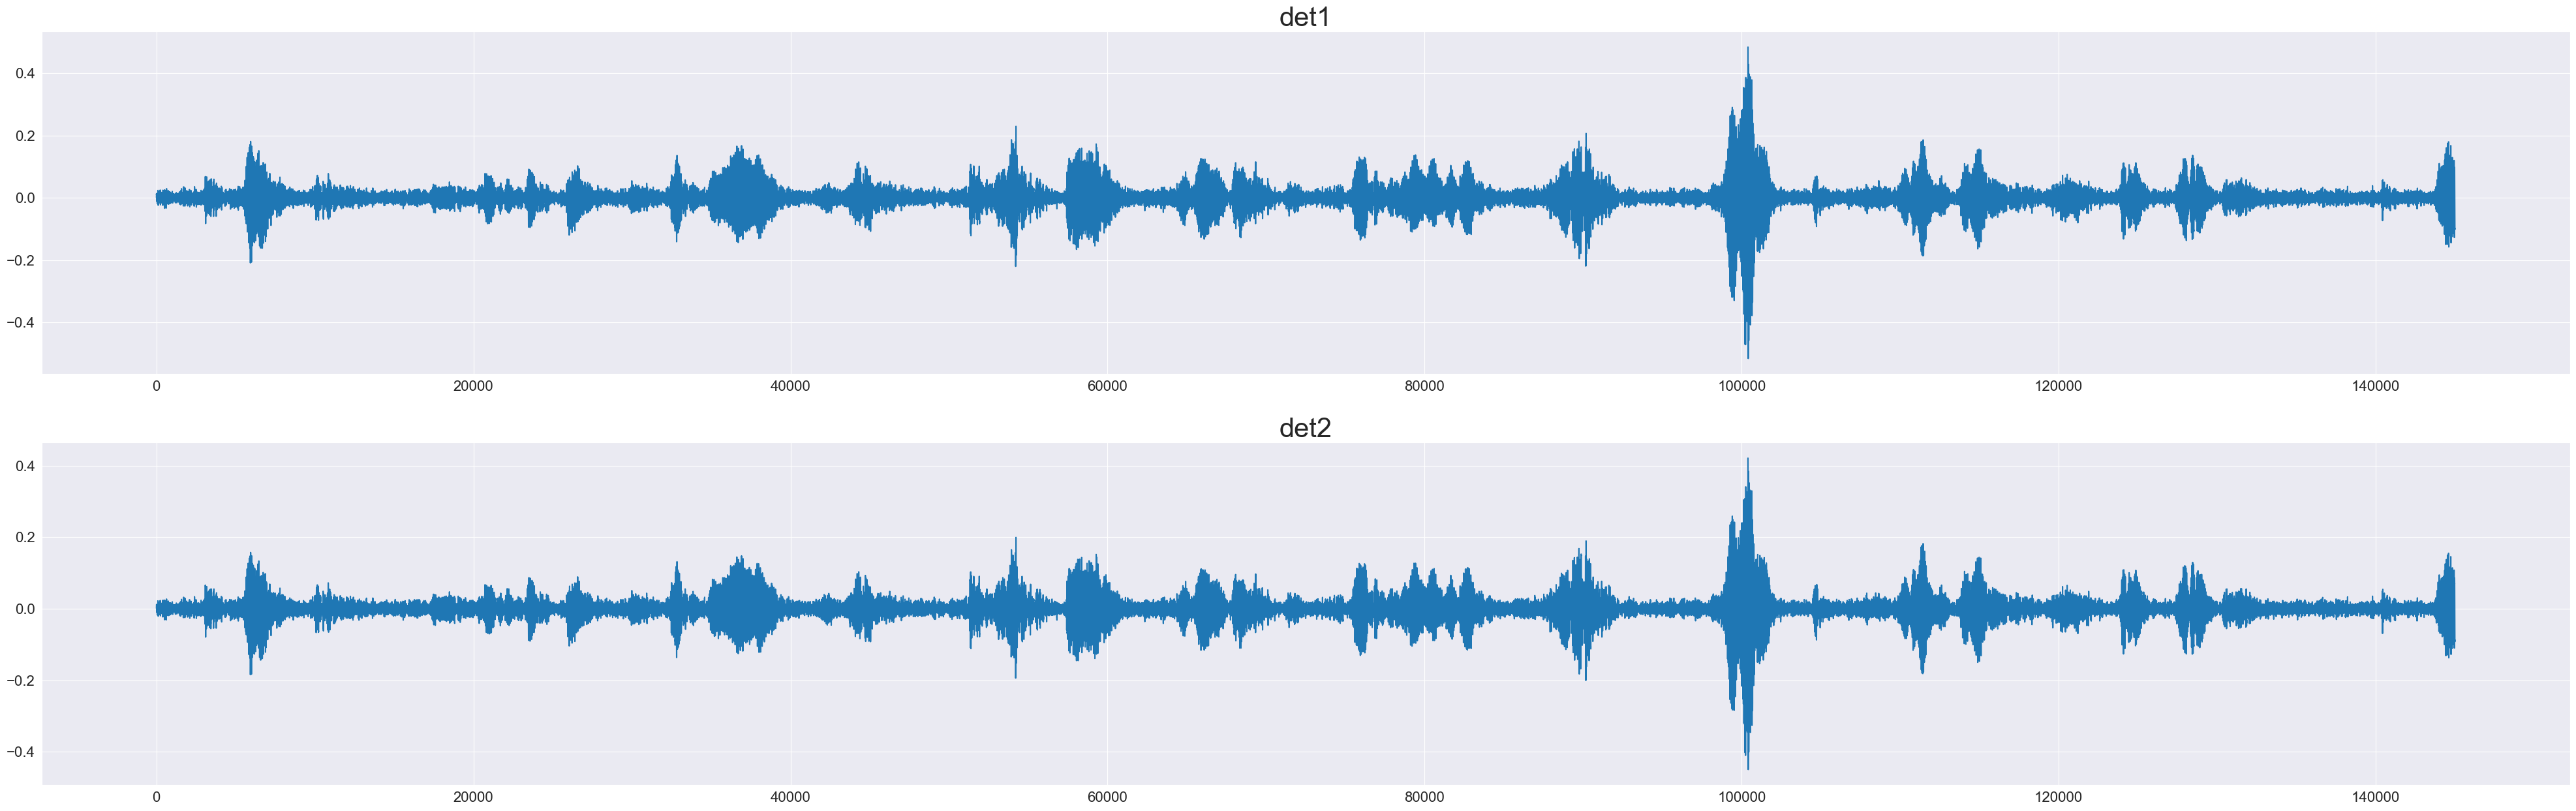

In [5]:
shift = 55_000
n = min(len(det1), len(det2) - shift)

x = det1[:n]
y = det2[shift:shift + n]

fig, ax = plt.subplots(2,1, figsize=(50,15))
ax[0].plot(x)
ax[1].plot(y)

ax[0].set_title('det1', fontsize=30)
ax[1].set_title('det2', fontsize=30)

for i in ax:
    i.tick_params(axis='both', labelsize=16)

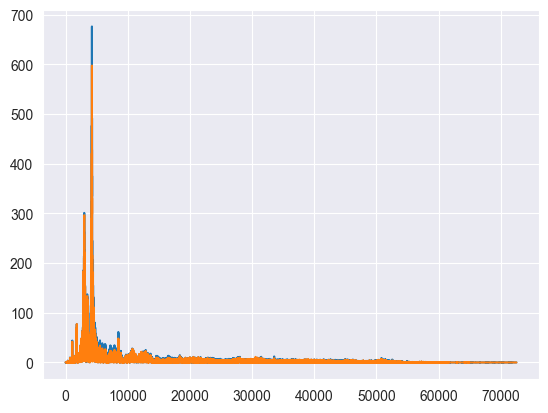

In [6]:
X1 = np.fft.fft(x)[:72499]
X2 = np.fft.fft(y)[:72499]
AFC = abs(X2) / abs(X1)
plt.plot(abs(X1))
plt.plot(abs(X2))

In [7]:
len(x)

144998

In [8]:
np.median(AFC)

np.float64(0.8583282052157817)

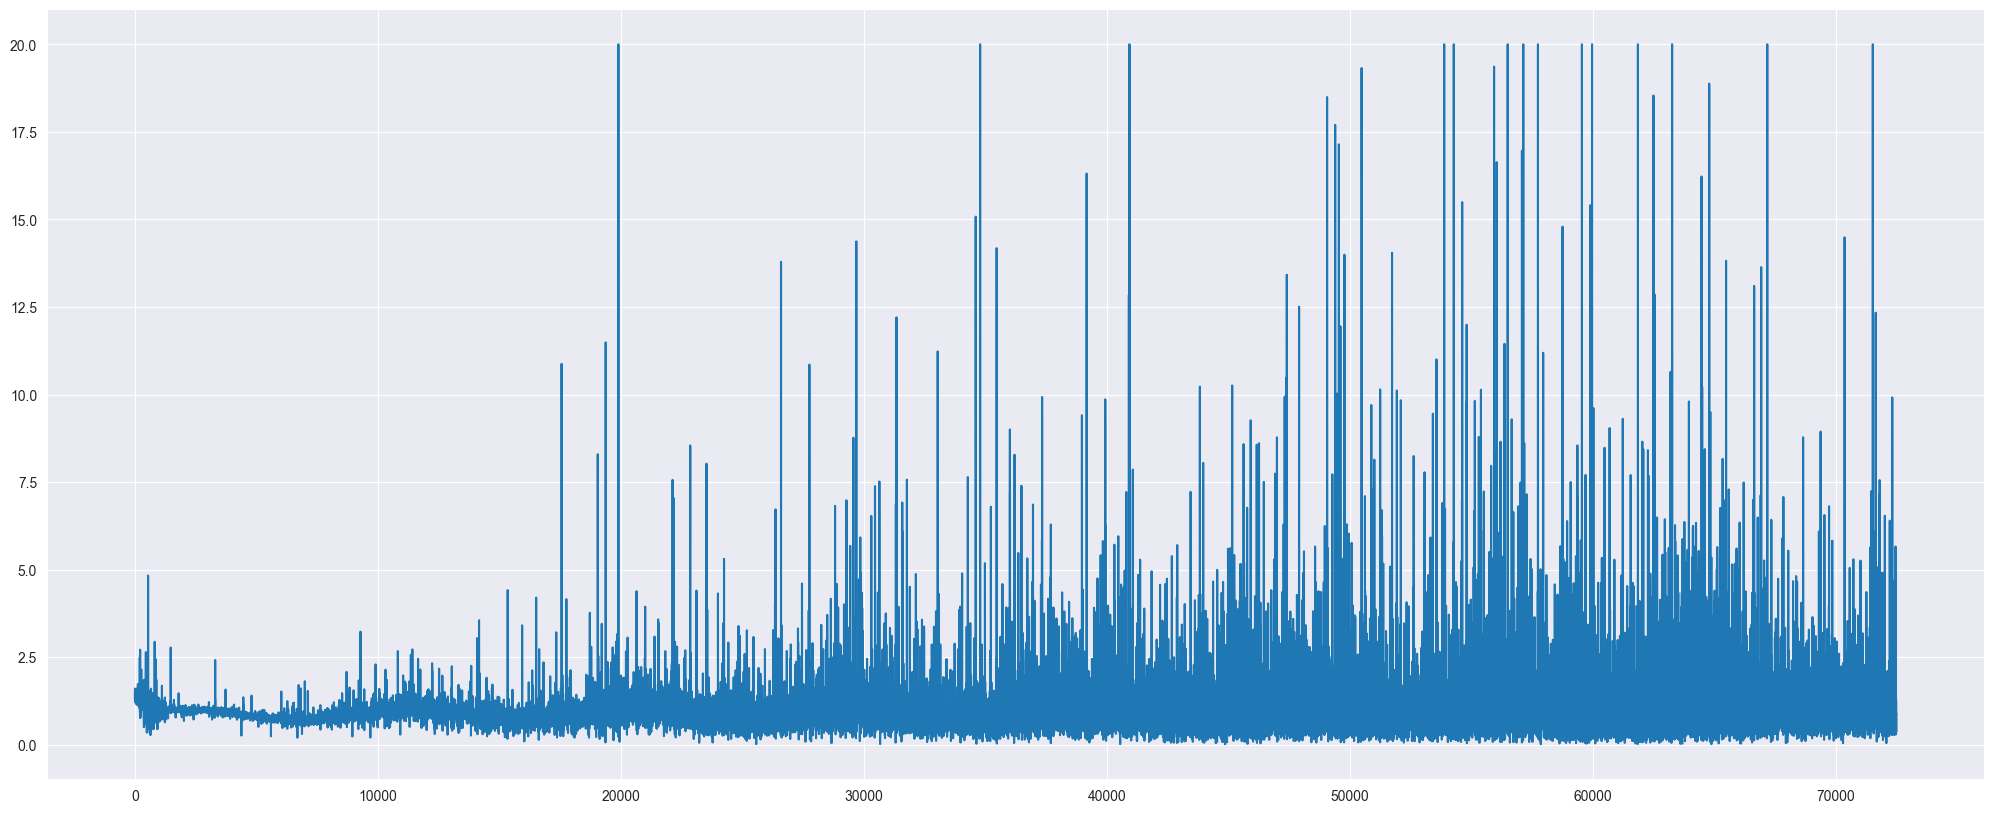

In [9]:

fig = plt.figure(figsize=(25,10))
plt.plot(np.clip(AFC, 0, 20))

72500
72499


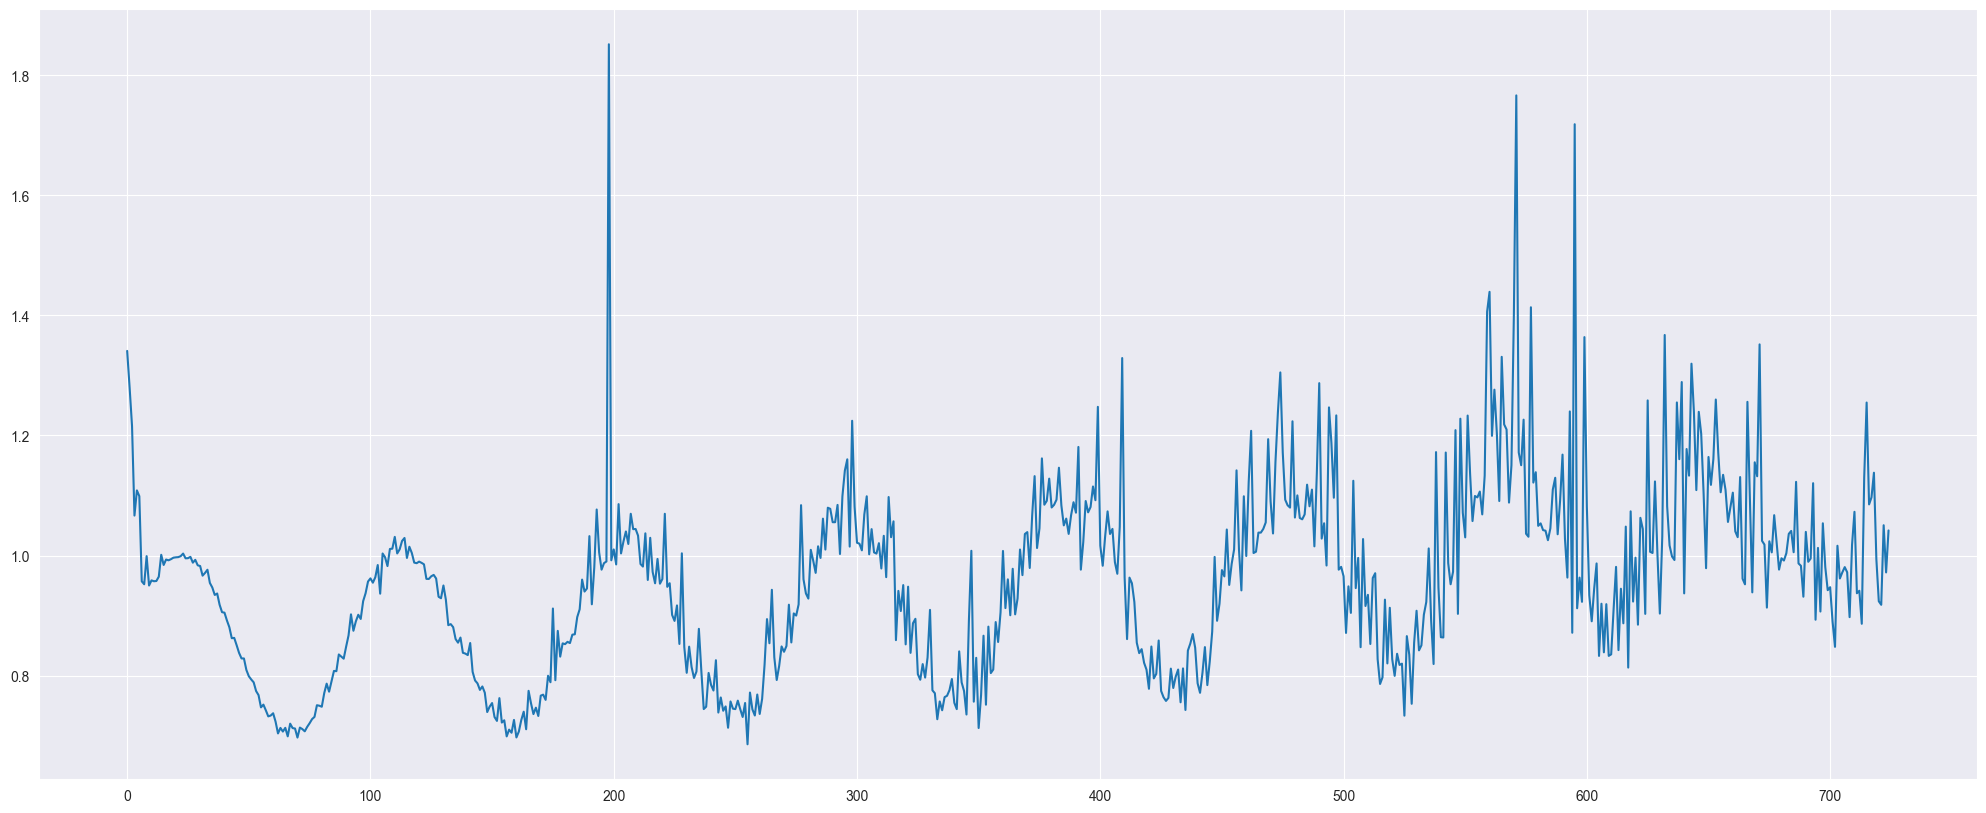

In [20]:
mean_afc = np.pad(AFC, (0, (-len(AFC)) % 100), constant_values= AFC[-1])
print(len(mean_afc))
print(len(AFC))
mean_afc = mean_afc.reshape( -1, 100)
mean_afc = mean_afc.mean(axis = 1)
fig = plt.figure(figsize=(25,10))
plt.plot(np.clip(mean_afc, 0, 20))